# 주성분 분석(PCA)

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**권장 사항**

[(강의노트) 주성분 분석(PCA)](https://codingalzi.github.io/code-workout-ml/pca/)을 병행하여 읽을 것을 권장한다.

## 환경설정

This project requires Python 3.10 or above:

In [2]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [3]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 사이킷런의 `PCA` 모델

아래 코드는 3차원 훈련셋을 생성한다.

In [5]:
import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
rng = np.random.default_rng(seed=42)
angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * rng.standard_normal((m, 3))  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

아래 코드는 데이터셋의 차원을 2로 줄인다.
`PCA` 모델은 변환기이기에 `fit_transform()` 메서드를 지원한다.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

### 설명 분산 비율

훈련된 `PCA` 모델의 `explained_variance_ratio_` 속성에는 각 주성분이 원 데이터셋의 분산을 얼마나 설명하는지가 저장된다.

예를 들어 아래 사영 그림에서 3차원 데이터를 새로운 축 `z1`과 `z2`를 사용하는 2차원 평면 위의 데이터로 표현하면, 두 축에 대한 설명 분산 비율은 각각 82.3%와 10.8%이다.

따라서 이 두 주성분만 사용해도 원 데이터셋의 분산 중 약 93%를 유지하면서 데이터를 2차원으로 축소할 수 있다.

In [7]:
pca.explained_variance_ratio_

array([0.82279334, 0.10821224])

### 적절한 차원 선택

일반적으로는 누적 설명 분산 비율이 95% 이상이 되도록 주성분의 개수를 정하는 방법이 자주 사용된다.
반면 데이터 시각화가 목적이라면 사람이 눈으로 확인할 수 있도록 2개 또는 3개의 주성분만 선택한다.

적절한 차원을 결정하기 위해 설명 분산 비율의 누적합과 차원 사이의 그래프를 활용할 수 있다.
예를 들어 설명 분산 비율의 누적합 증가가 완만하게 변하는 지점, 즉 팔꿈치<font size='2'>elbow</font> 지점을 살펴보면 좋다.

아래 코드는 MNIST 데이터셋에 대해 누적 설명 분산 비율이 95% 이상이 되도록 하는 차원이 154임을 확인해준다.

In [8]:
from sklearn.datasets import fetch_openml

# MNIST 데이터셋 불러오기
mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

# PCA를 사용하여 MNIST 데이터셋의 주성분 분석 수행
pca = PCA()
pca.fit(X_train)

# 누적 설명 분산 비율 계산
cumsum = np.cumsum(pca.explained_variance_ratio_)

# 95% 이상의 분산을 설명하는 데 필요한 주성분의 수 계산
d = np.argmax(cumsum >= 0.95) + 1  # d equals 154
d

np.int64(154)

아래 코드는 누적 설명 분산 비율의 변화를 그래프로 그린다.

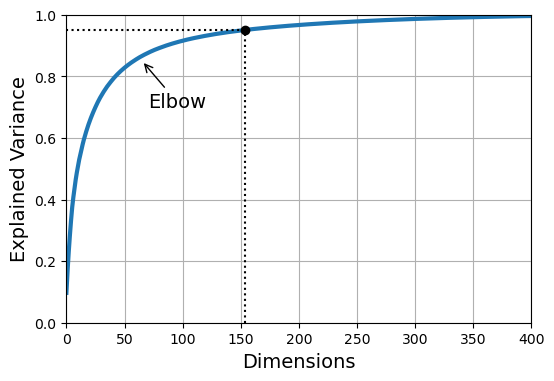

In [9]:
plt.figure(figsize=(6, 4))

# 누적 설명 분산 비율 그래프
plt.plot(cumsum, linewidth=3) 
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")

# 엘보우 지점 표시
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))

plt.grid(True)
plt.show()

## PCA 활용

**예제: PCA 전처리**

아래 코드는 차원 축소를 담당하는 PCA와 랜덤 포레스트 분류기를 하나의 파이프라인으로 묶은 후, 랜덤 탐색을 이용하여 **적절한 주성분 개수와 랜덤 포레스트의 트리 개수를 함께 찾는다**.

아래 코드는 훈련 시간을 줄이기 위해 1,000개의 훈련 샘플만 이용한다.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))

param_distrib = {
    "pca__n_components": np.arange(100, 200, 10),
    "randomforestclassifier__n_estimators": np.arange(100, 1000, 100)
}

rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)

rnd_search.fit(X_train[:1000], y_train[:1000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': array([100, 1...70, 180, 190]), 'randomforestclassifier__n_estimators': array([100, 2...00, 800, 900])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versio

랜던 탐색 결과 찾아낸 최적의 줭분 개수와 트리 개수는 다음과 같다.
물론 훈련셋 1,000개를 이용한 결과임에 주의해야 한다.

In [11]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(900), 'pca__n_components': np.int64(140)}


## 대용량 데이터셋을 위한 PCA

### 랜덤 PCA

랜덤 PCA는 주성분을 계산할 때 사용하는 SVD를 확률적 알고리즘으로 근사하는 기법이다.
전체 SVD를 정확히 계산하지 않고, 지정된 개수의 주성분에 대한 근삿값을 더 빠르게 찾는다.

In [12]:
rnd_pca = PCA(n_components=154, 
              svd_solver="randomized", 
              random_state=42)

X_reduced = rnd_pca.fit_transform(X_train)

### 점진적 PCA (IPCA)

점진적 PCA, 즉 IPCA(Incremental PCA)는 훈련 세트를 미니배치로 나눈 후 하나씩 주입하여 학습하는 PCA 기법이다.
전체 훈련 세트를 한 번에 메모리에 올리기 어려운 경우나 온라인 학습에 활용할 수 있다.
IPCA는 훈련에 `partial_fit()` 메서드를 사용한다.

In [13]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)

for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

**넘파이 `memmap` 클래스 활용**

넘파이의 `memmap` 클래스는 바이너리 파일로 저장된 매우 큰 데이터셋을 메모리에 모두 올리지 않고도, 일반 배열과 비슷한 방식으로 다룰 수 있게 해준다.
이를 이용하면 큰 데이터셋에 대해서도 미니배치 방식의 점진적 PCA를 적용할 수 있다.

- 메모리 맵 파일 저장

In [26]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='w+', shape=X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

- 메모리 맵을 활용한 `IncrementalPCA` 적용: 아래 코드에서 `IncrementalPCA.fit()`은 `batch_size`에 맞춰 데이터를 나누어 내부적으로 여러 번 `partial_fit()`을 호출한다.

In [27]:
X_mmap = np.memmap(filename, dtype="float32", mode="r", shape=X_train.shape)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",154
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",600


- MNIST 데이터 압축

In [28]:
X_reduced = inc_pca.transform(X_train)
X_reduced.shape

(60000, 154)

참고: 아래 코드는 여전히 읽기 전용으로 열려 있는 `X_map` 객체를 메모리에서 제거한다.

In [22]:
del X_mmap
import gc
gc.collect()

0

## 연습문제

### 문제 1: PCA와 모델 훈련

PCA가 훈련 속도와 성능에 미치는 영향을 조사하기 위해
MNISt 데이터셋을 활용한다.

아래 코드는 MINIST 데이터셋을 불러와 훈련셋과 테스트셋으로 나눈다.

In [29]:
mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

(1) 랜덤 포레스트 분류기를 훈련시키고 훈련 시간과 테스트 성능을 확인하라.

답:

In [30]:
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)

%time rnd_clf.fit(X_train, y_train)

CPU times: total: 22.7 s
Wall time: 23.1 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

테스트셋에 대한 정확도는 97% 정도이다.

In [34]:
from sklearn.metrics import accuracy_score

y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9705

(2) 설명 분산 비율이 95%가 되도록 PCA로 차원을 축소하라.

답:

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)

(3) 축소된 데이터셋에 랜덤 포레스트 분류기를 다시 훈련시키고 시간을 비교하라.

답:

In [32]:
rnd_clf_with_pca = RandomForestClassifier(n_estimators=100, random_state=42)

%time rnd_clf_with_pca.fit(X_train_reduced, y_train)

CPU times: total: 51.5 s
Wall time: 52.5 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

오히려 훈련 시간이 약 두 배 느려졌다. 차원 축소가 항상 훈련 속도를 높이는 것은 아니며, 효과는 데이터셋과 모델에 따라 달라진다.

(4) 테스트 세트에서 분류기를 평가하고 이전 결과와 비교하라.

답:

테스트셋도 차원 축소를 먼저 적용한 후에 정확도를 계산한다.

In [35]:
X_test_reduced = pca.transform(X_test)

y_pred = rnd_clf_with_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred)

0.9488

차원 축소 후 성능이 떨어졌다.
즉, MNIST와 랜덤 포레스트 모델의 경우 PCA는 훈련을 느리게 만들고 성능도 낮추었다.

(5) `SGDClassifier`로 다시 시도하고 PCA의 효과를 확인하라.

답:

- PCA 적용 전

In [36]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

%time sgd_clf.fit(X_train, y_train)

CPU times: total: 1min 15s
Wall time: 1min 17s


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [37]:
y_pred = sgd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8674

`SGDClassifier`는 이 MNiST 데이터셋에 대해 훈련도 느리고 성능도 낮다.

- PCA 적용 후

In [38]:
sgd_clf_with_pca = SGDClassifier(random_state=42)

%time sgd_clf_with_pca.fit(X_train_reduced, y_train)

CPU times: total: 18.2 s
Wall time: 18.5 s


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


차원을 축소하니 훈련 속도가 대략 4배 빨라졌다. 이제 정확도를 확인해보자.

In [39]:
y_pred = sgd_clf_with_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred)

0.8931

PCA가 훈련 속도를 높였고 성능도 약간 향상시켰다.

(6) PCA의 효과에 대한 결론을 내려라.

답:

PCA는 훈련 속도와 성능을 개선할 수 있지만, 효과는 모델과 데이터셋에 따라 달라진다.